# Lab 06 – Solved Tasks
**FAST NUCES – Karachi** | Computer Vision / Signal Processing

| # | Task | Technique |
|---|------|-----------|
| 1 | Computer Screen Detection in a Computer Lab | Hough Line Transform |
| 2 | Asset Tracking in a Computer Lab | SIFT |
| 3 | Anomaly Detection in Sensor Data | Wavelet Transform |
| 4 | Object Recognition (Using Video) | SIFT + Homography |
| 5 | Your Panoramic Image | SIFT stitching |
| 6 | Lane Detection | Hough Line Transform |
| 7 | Coins Detection and Counting | Hough Circle Transform |
| 8 | Smart Security System | Boundary / contour detection + alarm |

**How to use:** every task has a `*_PATH` variable. Set it to your own image/video to use real data.
If it is `None` (default) the notebook generates a **synthetic test input**, so every cell runs end-to-end without any files.

## 0. Setup & helpers

In [1]:
# !pip install opencv-python numpy matplotlib PyWavelets
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pywt

rng = np.random.default_rng(42)

def show(img, title="", size=(10, 6), cmap=None):
    """Display a BGR / gray image with matplotlib."""
    plt.figure(figsize=size)
    if img.ndim == 3:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap=cmap or "gray")
    plt.title(title); plt.axis("off"); plt.show()

def show_grid(imgs, titles=None, cols=3, size=(15, 4)):
    rows = int(np.ceil(len(imgs) / cols))
    plt.figure(figsize=(size[0], size[1] * rows))
    for i, im in enumerate(imgs):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB) if im.ndim == 3 else im, cmap="gray")
        if titles: plt.title(titles[i], fontsize=9)
        plt.axis("off")
    plt.tight_layout(); plt.show()

def make_template(label, size=(260, 200), seed=0):
    """Synthetic, feature-rich 'object' image (used where SIFT needs a textured object)."""
    r = np.random.default_rng(seed)
    w, h = size
    t = np.full((h, w, 3), 230, np.uint8)
    for _ in range(45):
        p1 = (int(r.integers(0, w)), int(r.integers(0, h)))
        p2 = (int(r.integers(0, w)), int(r.integers(0, h)))
        col = tuple(int(v) for v in r.integers(0, 255, 3))
        cv2.rectangle(t, p1, p2, col, -1 if r.random() < 0.5 else 2)
    cv2.putText(t, label, (12, h // 2 + 10), cv2.FONT_HERSHEY_SIMPLEX, 1.1, (0, 0, 0), 3)
    cv2.rectangle(t, (0, 0), (w - 1, h - 1), (0, 0, 0), 4)
    return t

def place(scene, tpl, center, angle=0, scale=1.0):
    """Paste template into scene with rotation + scale (affine)."""
    h, w = tpl.shape[:2]
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, scale)
    M[:, 2] += np.array(center) - np.array([w / 2, h / 2])
    warped = cv2.warpAffine(tpl, M, (scene.shape[1], scene.shape[0]))
    mask = cv2.warpAffine(np.full((h, w), 255, np.uint8), M, (scene.shape[1], scene.shape[0]))
    scene[mask > 0] = warped[mask > 0]
    return scene

print("OpenCV", cv2.__version__)

OpenCV 4.14.0


---
## Task 1 – Computer Screen Detection in a Computer Lab (Hough Line Transform)
**Pipeline:** grayscale → blur → Canny edges → `HoughLinesP` → keep horizontal / vertical lines →
close them into rectangles → bounding boxes of screens → **ON/OFF** from brightness inside the box →
**missing screens** by comparing the number found per row to the expected number per row.

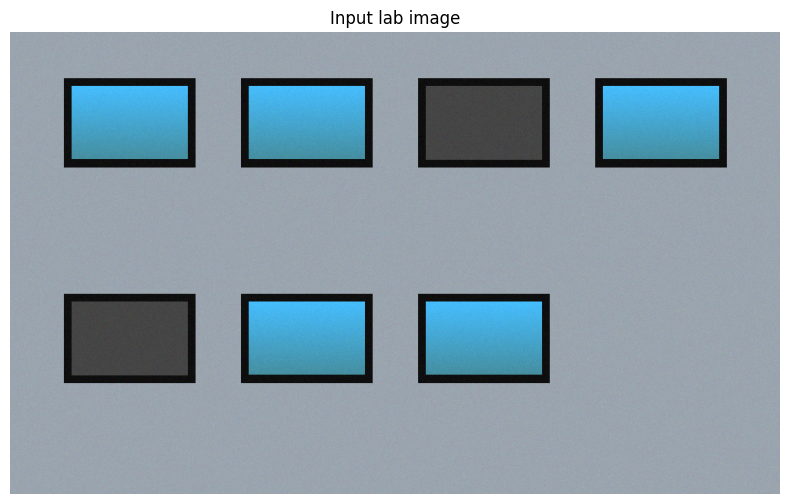

In [2]:
LAB_IMAGE_PATH = None          # e.g. "lab.jpg"
EXPECTED_ROWS, EXPECTED_COLS = 2, 4

def make_lab_image(rows=2, cols=4, off=((0, 2), (1, 0)), missing=((1, 3),), W=1000, H=600):
    img = np.full((H, W, 3), (175, 165, 155), np.uint8)
    sw, sh = 150, 95
    xs = np.linspace(80, W - 80 - sw, cols).astype(int)
    ys = [70 + r * 280 for r in range(rows)]
    for r, y in enumerate(ys):
        for c, x in enumerate(xs):
            if (r, c) in missing: continue
            cv2.rectangle(img, (x - 10, y - 10), (x + sw + 10, y + sh + 10), (15, 15, 15), -1)   # bezel
            if (r, c) in off:
                cv2.rectangle(img, (x, y), (x + sw, y + sh), (70, 70, 70), -1)                   # screen OFF
            else:
                for i in range(sh):                                                              # screen ON (gradient)
                    cv2.line(img, (x, y + i), (x + sw, y + i), (255 - i, 190 - i // 2, 70), 1)
    noise = rng.normal(0, 4, img.shape)
    return np.clip(img + noise, 0, 255).astype(np.uint8)

lab = cv2.imread(LAB_IMAGE_PATH) if LAB_IMAGE_PATH else make_lab_image()
show(lab, "Input lab image")

Screens detected: 7  (expected 8)
  Row 1: 4 screens, ON=3
  Row 2: 3 screens, ON=2  ⚠ 1 MISSING


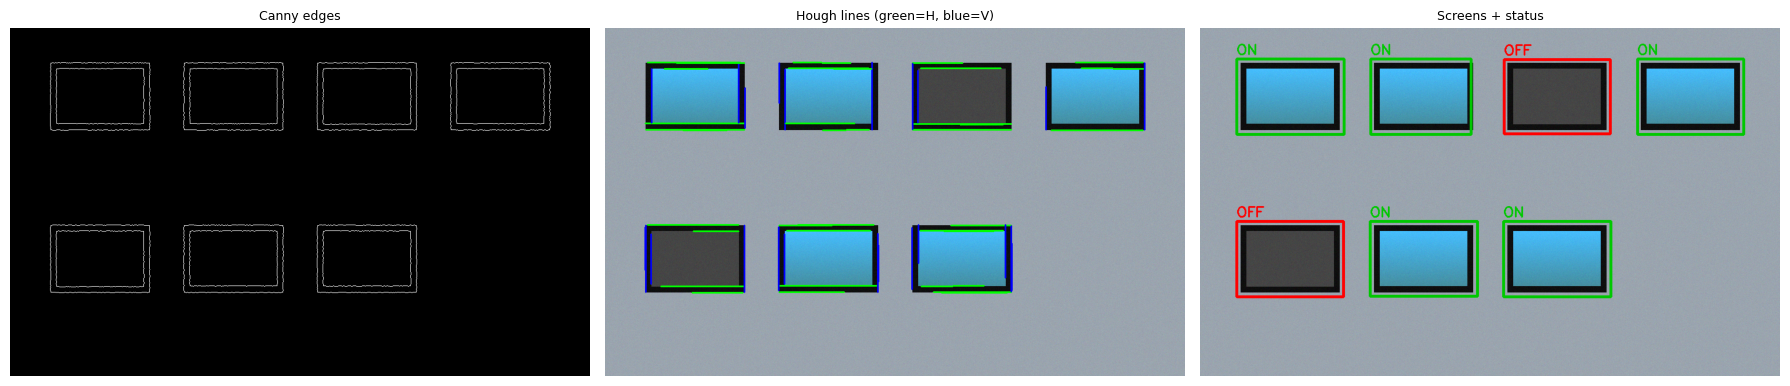

In [3]:
def detect_screens(img, min_area=5000):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blur, 50, 150)

    lines = cv2.HoughLinesP(edges, rho=1, theta=np.pi / 180, threshold=60,
                            minLineLength=60, maxLineGap=10)
    line_mask = np.zeros_like(gray)
    line_vis = img.copy()
    n_h = n_v = 0
    for l in (lines if lines is not None else []):
        x1, y1, x2, y2 = l[0]
        ang = abs(np.degrees(np.arctan2(y2 - y1, x2 - x1)))
        if ang < 10 or ang > 170:   n_h += 1; col = (0, 255, 0)      # horizontal edge
        elif 80 < ang < 100:        n_v += 1; col = (255, 0, 0)      # vertical edge
        else: continue
        cv2.line(line_mask, (x1, y1), (x2, y2), 255, 3)
        cv2.line(line_vis, (x1, y1), (x2, y2), col, 2)

    # connect horizontal + vertical edges into closed screen outlines
    line_mask = cv2.dilate(line_mask, np.ones((5, 5), np.uint8), iterations=2)
    cnts, _ = cv2.findContours(line_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    boxes = []
    for c in cnts:
        x, y, w, h = cv2.boundingRect(c)
        if w * h >= min_area and 0.8 < w / h < 2.5:
            boxes.append((x, y, w, h))
    return boxes, line_vis, edges

def screen_status(img, box, shrink=0.2):
    x, y, w, h = box
    dx, dy = int(w * shrink), int(h * shrink)
    roi = cv2.cvtColor(img[y + dy:y + h - dy, x + dx:x + w - dx], cv2.COLOR_BGR2GRAY)
    return "ON" if roi.mean() > 110 else "OFF"

boxes, line_vis, edges = detect_screens(lab)
boxes = sorted(boxes, key=lambda b: (round(b[1] / 100), b[0]))

result = lab.copy()
for (x, y, w, h) in boxes:
    st = screen_status(lab, (x, y, w, h))
    col = (0, 200, 0) if st == "ON" else (0, 0, 255)
    cv2.rectangle(result, (x, y), (x + w, y + h), col, 3)
    cv2.putText(result, st, (x, y - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.8, col, 2)

# ---- anomaly: missing screens (group boxes into rows by y-centre)
rows = {}
for b in boxes:
    rows.setdefault(round((b[1] + b[3] / 2) / 120), []).append(b)
print(f"Screens detected: {len(boxes)}  (expected {EXPECTED_ROWS * EXPECTED_COLS})")
for i, k in enumerate(sorted(rows)):
    n = len(rows[k]); miss = EXPECTED_COLS - n
    print(f"  Row {i + 1}: {n} screens, ON={sum(screen_status(lab, b) == 'ON' for b in rows[k])}"
          + (f"  ⚠ {miss} MISSING" if miss > 0 else ""))
if len(rows) < EXPECTED_ROWS: print(f"  ⚠ {EXPECTED_ROWS - len(rows)} whole row(s) missing")

show_grid([edges, line_vis, result], ["Canny edges", "Hough lines (green=H, blue=V)", "Screens + status"], cols=3, size=(18, 4))

---
## Task 2 – Asset Tracking in a Computer Lab (SIFT)
Reference images of each asset type (monitor, keyboard, CPU, …) are matched to the lab scene with SIFT descriptors
(Lowe ratio test) and RANSAC homography. Every verified instance is outlined and added to an **inventory**.
After an instance is found its keypoints are removed so multiple copies of the same asset can be counted.

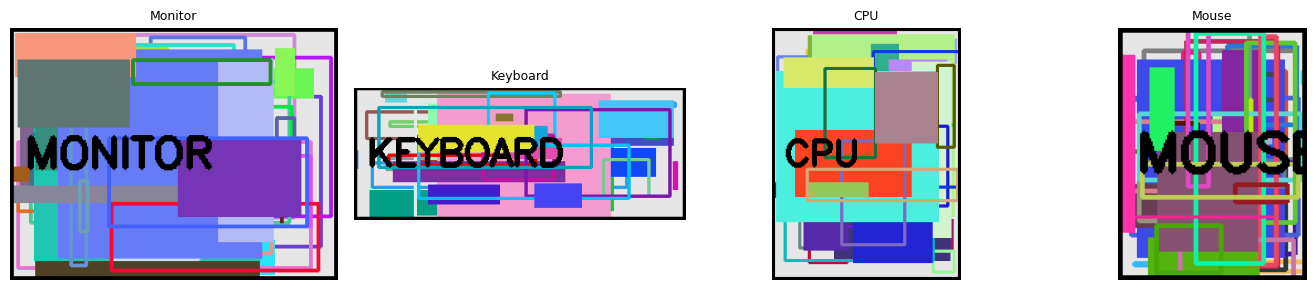

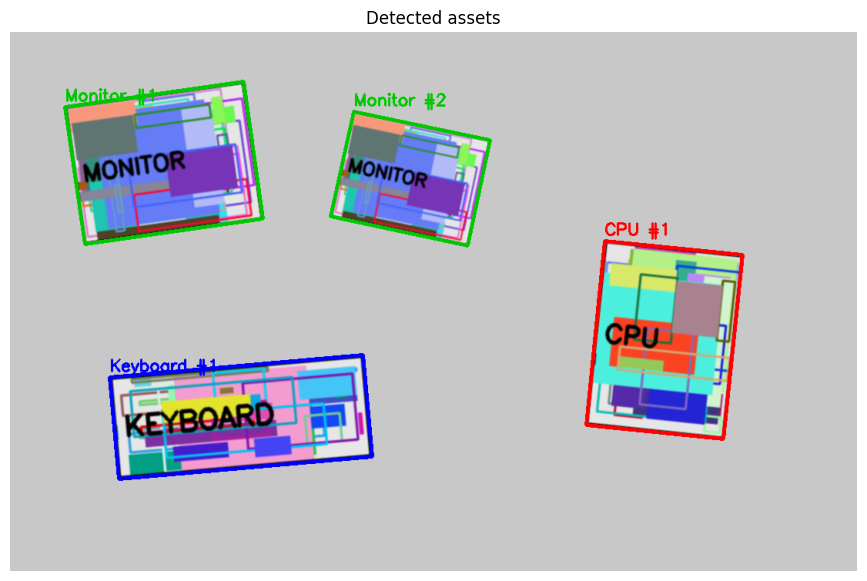

=== INVENTORY ===
Monitor   : 2
Keyboard  : 1
CPU       : 1
Mouse     : 0


In [4]:
ASSET_REFERENCES = None   # e.g. {"Monitor": "monitor.jpg", "Keyboard": "kb.jpg"};  ASSET_SCENE_PATH = "lab.jpg"
ASSET_SCENE_PATH = None

if ASSET_REFERENCES:
    refs = {k: cv2.imread(v) for k, v in ASSET_REFERENCES.items()}
    scene = cv2.imread(ASSET_SCENE_PATH)
else:   # synthetic demo: 2 monitors (different scale/rotation), 1 keyboard, 1 CPU, 0 mice
    refs = {"Monitor": make_template("MONITOR", seed=1),
            "Keyboard": make_template("KEYBOARD", (300, 120), seed=2),
            "CPU": make_template("CPU", (180, 240), seed=3),
            "Mouse": make_template("MOUSE", (120, 160), seed=4)}
    scene = np.full((700, 1100, 3), 200, np.uint8)
    place(scene, refs["Monitor"], (200, 170), angle=8, scale=0.9)
    place(scene, refs["Monitor"], (520, 190), angle=-12, scale=0.7)
    place(scene, refs["Keyboard"], (300, 500), angle=5, scale=1.1)
    place(scene, refs["CPU"], (850, 400), angle=-6, scale=1.0)
    scene = cv2.GaussianBlur(scene, (3, 3), 0)

sift = cv2.SIFT_create()
bf = cv2.BFMatcher(cv2.NORM_L2)

def find_instances(ref, scene, ratio=0.75, min_inliers=12, max_instances=5):
    """Return list of (corners, n_inliers) for every instance of `ref` found in `scene`."""
    g_ref = cv2.cvtColor(ref, cv2.COLOR_BGR2GRAY); g_sc = cv2.cvtColor(scene, cv2.COLOR_BGR2GRAY)
    kp_r, des_r = sift.detectAndCompute(g_ref, None)
    kp_s, des_s = sift.detectAndCompute(g_sc, None)
    alive = np.ones(len(kp_s), bool)
    found = []
    h, w = g_ref.shape
    for _ in range(max_instances):
        idx = np.where(alive)[0]
        if len(idx) < min_inliers: break
        pairs = bf.knnMatch(des_r, des_s[idx], k=2)
        good = [m for m, n in (p for p in pairs if len(p) == 2) if m.distance < ratio * n.distance]
        if len(good) < min_inliers: break
        src = np.float32([kp_r[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
        dst = np.float32([kp_s[idx[m.trainIdx]].pt for m in good]).reshape(-1, 1, 2)
        H, inl = cv2.findHomography(src, dst, cv2.RANSAC, 5.0)
        if H is None or inl.sum() < min_inliers: break
        corners = cv2.perspectiveTransform(np.float32([[0, 0], [w, 0], [w, h], [0, h]]).reshape(-1, 1, 2), H)
        found.append((corners, int(inl.sum())))
        for m, ok in zip(good, inl.ravel()):          # remove used keypoints -> look for another copy
            if ok: alive[idx[m.trainIdx]] = False
    return found

palette = [(0, 200, 0), (255, 0, 0), (0, 0, 255), (0, 160, 255), (200, 0, 200)]
out = scene.copy(); inventory = {}
for i, (name, ref) in enumerate(refs.items()):
    inst = find_instances(ref, scene)
    inventory[name] = len(inst)
    for j, (c, n) in enumerate(inst):
        cv2.polylines(out, [np.int32(c)], True, palette[i % 5], 3)
        p = tuple(np.int32(c[0, 0]))
        cv2.putText(out, f"{name} #{j + 1}", (p[0], max(p[1] - 8, 15)), cv2.FONT_HERSHEY_SIMPLEX, 0.7, palette[i % 5], 2)

show_grid(list(refs.values()), list(refs.keys()), cols=4, size=(14, 3))
show(out, "Detected assets", size=(12, 7))
print("=== INVENTORY ===")
for k, v in inventory.items(): print(f"{k:10s}: {v}")

---
## Task 3 – Anomaly Detection in Sensor Data (Wavelet Transform)
1. Decompose the signal with a Daubechies-4 DWT (`pywt.wavedec`).
2. Estimate noise σ from the finest detail coefficients (MAD / 0.6745) and soft-threshold the details (**universal threshold** σ√(2 ln N)).
3. Reconstruct → **denoised signal**.
4. **Residual** = original − denoised. Points whose residual is beyond ±3 robust-σ are flagged as **anomalies**.

Noise sigma = 0.953 | threshold = 3.543 | anomalies found = 14
Anomaly indices: [94, 100, 184, 295, 325, 342, 395, 524, 618, 734, 745, 802, 876, 937]


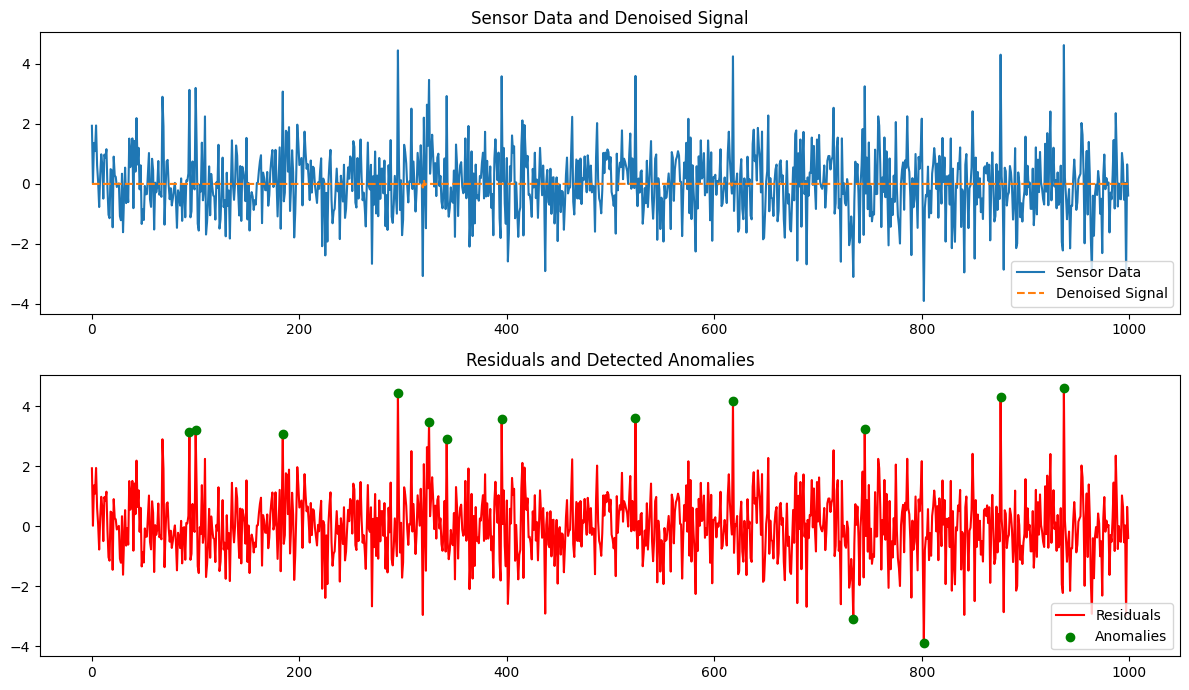

In [5]:
SENSOR_CSV = None            # e.g. "sensor.csv" (one column) – otherwise synthetic data is used

if SENSOR_CSV:
    data = np.loadtxt(SENSOR_CSV, delimiter=",")
else:
    n = 1000
    data = rng.normal(0, 1.0, n)                                  # noisy machine reading
    spikes = rng.choice(n, 20, replace=False)                     # injected faults
    data[spikes] += rng.choice([-1, 1], 20) * rng.uniform(2.5, 4, 20)

wavelet, level = "db4", 4
coeffs = pywt.wavedec(data, wavelet, level=level)

sigma = np.median(np.abs(coeffs[-1])) / 0.6745
thr = sigma * np.sqrt(2 * np.log(len(data)))
den_coeffs = [coeffs[0] * 0] + [pywt.threshold(c, thr, mode="soft") for c in coeffs[1:]]  # drop approx (trend ~ 0) like the expected output
denoised = pywt.waverec(den_coeffs, wavelet)[:len(data)]

residual = data - denoised
r_med = np.median(residual)
r_sig = 1.4826 * np.median(np.abs(residual - r_med))              # robust std (MAD)
anom_idx = np.where(np.abs(residual - r_med) > 3 * r_sig)[0]

print(f"Noise sigma = {sigma:.3f} | threshold = {thr:.3f} | anomalies found = {len(anom_idx)}")
print("Anomaly indices:", anom_idx.tolist())

fig, ax = plt.subplots(2, 1, figsize=(12, 7))
ax[0].plot(data, label="Sensor Data"); ax[0].plot(denoised, "--", label="Denoised Signal")
ax[0].set_title("Sensor Data and Denoised Signal"); ax[0].legend(loc="lower right")
ax[1].plot(residual, "r", label="Residuals")
ax[1].scatter(anom_idx, residual[anom_idx], c="g", zorder=3, label="Anomalies")
ax[1].set_title("Residuals and Detected Anomalies"); ax[1].legend(loc="lower right")
plt.tight_layout(); plt.show()

---
## Task 4 – Object Recognition (Using Video) – SIFT
A reference image is described with SIFT once. For every video frame we compute SIFT features, match them using FLANN + ratio test,
estimate a homography with RANSAC and draw a **bounding box** around the object – robust to scale, rotation and partial occlusion.

Saved: object_recognition_out.mp4
Object found in 40/40 frames


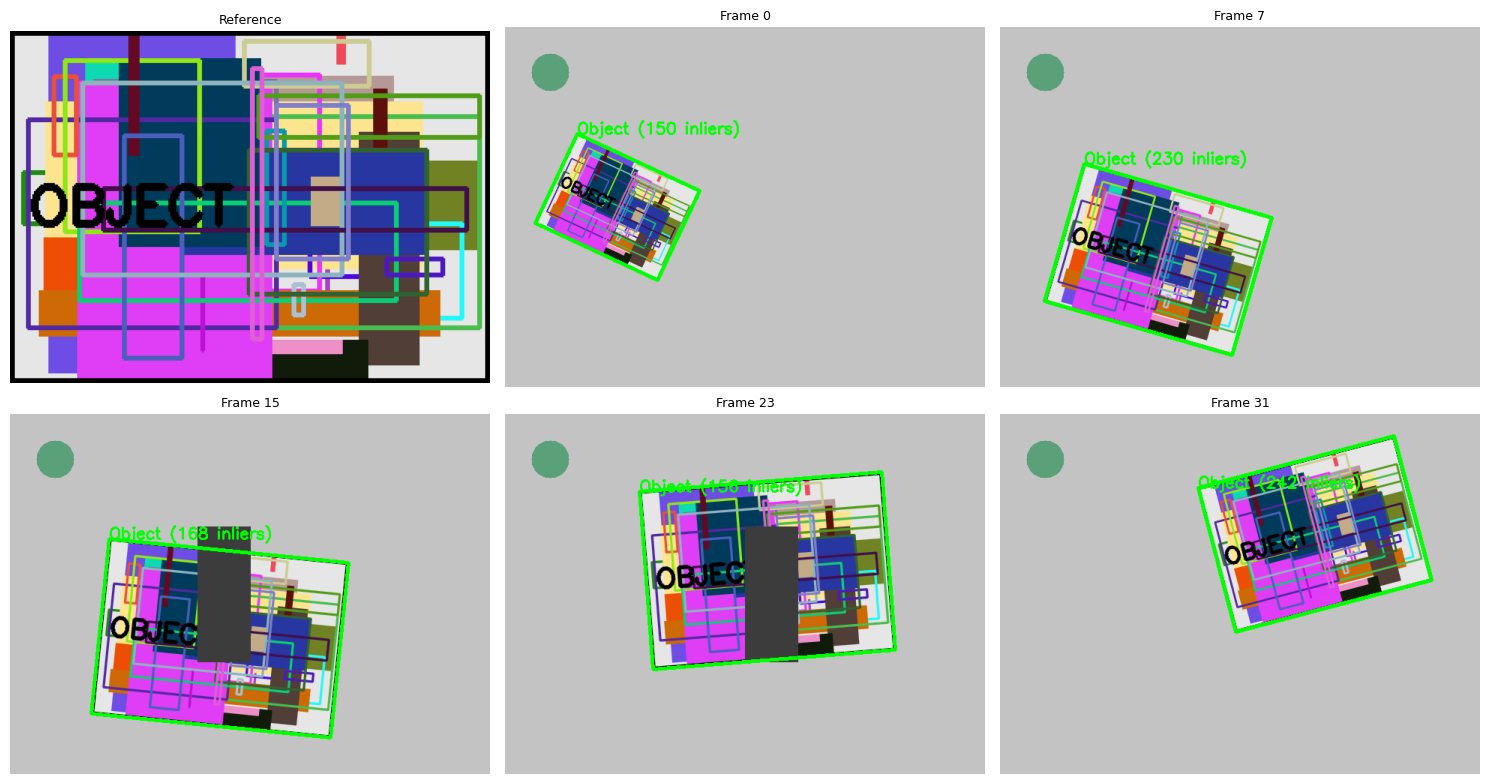

In [6]:
OBJ_REF_PATH   = None    # reference image of the object, e.g. "book.jpg"
OBJ_VIDEO_PATH = None    # test video, e.g. "test.mp4"  (0 = webcam)
SAVE_VIDEO     = "object_recognition_out.mp4"

ref_img = cv2.imread(OBJ_REF_PATH) if OBJ_REF_PATH else make_template("OBJECT", (300, 220), seed=11)

def synthetic_video(ref, n=40, size=(640, 480)):
    """Object moves, rotates, changes scale and is partially occluded in the middle frames."""
    W, H = size
    for i in range(n):
        f = np.full((H, W, 3), 195, np.uint8)
        cv2.circle(f, (60, 60), 25, (120, 160, 90), -1)
        t = i / (n - 1)
        place(f, ref, (int(150 + 340 * t), int(240 + 80 * np.sin(t * 6))), angle=-25 + 50 * t, scale=0.6 + 0.5 * np.sin(np.pi * t))
        if 15 <= i < 25: cv2.rectangle(f, (int(150 + 340 * t) - 30, 150), (int(150 + 340 * t) + 40, 330), (60, 60, 60), -1)  # occlusion
        yield f

def video_frames(path):
    if path is None:
        yield from synthetic_video(ref_img); return
    cap = cv2.VideoCapture(path)
    while True:
        ok, fr = cap.read()
        if not ok: break
        yield fr
    cap.release()

sift = cv2.SIFT_create()
kp_ref, des_ref = sift.detectAndCompute(cv2.cvtColor(ref_img, cv2.COLOR_BGR2GRAY), None)
flann = cv2.FlannBasedMatcher(dict(algorithm=1, trees=5), dict(checks=50))
hr, wr = ref_img.shape[:2]
ref_corners = np.float32([[0, 0], [wr, 0], [wr, hr], [0, hr]]).reshape(-1, 1, 2)

def recognize(frame, min_matches=10):
    kp, des = sift.detectAndCompute(cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY), None)
    if des is None or len(kp) < 2: return frame, 0
    pairs = flann.knnMatch(des_ref, des, k=2)
    good = [m for m, n in (p for p in pairs if len(p) == 2) if m.distance < 0.7 * n.distance]
    out = frame.copy()
    if len(good) >= min_matches:
        src = np.float32([kp_ref[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
        dst = np.float32([kp[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
        H, inl = cv2.findHomography(src, dst, cv2.RANSAC, 5.0)
        if H is not None and inl.sum() >= min_matches:
            box = np.int32(cv2.perspectiveTransform(ref_corners, H))
            cv2.polylines(out, [box], True, (0, 255, 0), 3)
            cv2.putText(out, f"Object ({int(inl.sum())} inliers)", tuple(box[0, 0]), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
            return out, int(inl.sum())
    cv2.putText(out, "Not found", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)
    return out, 0

writer, results, detected = None, [], 0
for i, fr in enumerate(video_frames(OBJ_VIDEO_PATH)):
    out, n = recognize(fr)
    detected += n > 0
    results.append(out)
    if SAVE_VIDEO:
        if writer is None:
            writer = cv2.VideoWriter(SAVE_VIDEO, cv2.VideoWriter_fourcc(*"mp4v"), 20, (out.shape[1], out.shape[0]))
        writer.write(out)
if writer: writer.release(); print("Saved:", SAVE_VIDEO)
print(f"Object found in {detected}/{len(results)} frames")

pick = np.linspace(0, len(results) - 1, 6).astype(int)
show_grid([ref_img] + [results[i] for i in pick[:5]], ["Reference"] + [f"Frame {i}" for i in pick[:5]], cols=3, size=(15, 4))

---
## Task 5 – Your Panoramic Image (SIFT stitching)
For each adjacent pair: SIFT keypoints → ratio-test matches → RANSAC homography → warp the new image into the base image's
coordinate frame on an enlarged canvas → merge → crop black borders. (OpenCV's built-in `cv2.Stitcher` is run for comparison.)

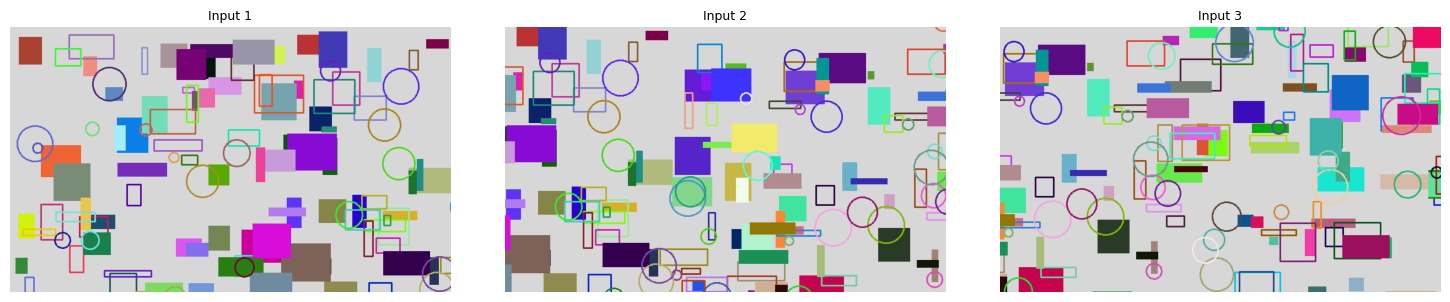

In [7]:
PANO_IMAGE_PATHS = []        # e.g. ["p1.jpg", "p2.jpg", "p3.jpg"]  (ordered left -> right)

if PANO_IMAGE_PATHS:
    pano_imgs = [cv2.imread(p) for p in PANO_IMAGE_PATHS]
else:   # synthetic: one wide scene, 3 overlapping "camera shots" with small vertical drift
    r = np.random.default_rng(5)
    big = np.full((520, 1900, 3), 215, np.uint8)
    for _ in range(260):
        p1 = (int(r.integers(0, 1900)), int(r.integers(0, 520)))
        p2 = (p1[0] + int(r.integers(10, 90)), p1[1] + int(r.integers(10, 70)))
        cv2.rectangle(big, p1, p2, tuple(int(v) for v in r.integers(0, 255, 3)), -1 if r.random() < .6 else 2)
    for _ in range(60):
        cv2.circle(big, (int(r.integers(0, 1900)), int(r.integers(0, 520))), int(r.integers(8, 35)), tuple(int(v) for v in r.integers(0, 255, 3)), 2)
    pano_imgs = [big[0:480, 0:800], big[15:495, 500:1300], big[30:510, 1000:1800]]

show_grid(pano_imgs, [f"Input {i + 1}" for i in range(len(pano_imgs))], cols=len(pano_imgs), size=(15, 3))

Stitching image 2 ...
   matches kept: 296
Stitching image 3 ...
   matches kept: 181
Panorama size: 1812 x 513


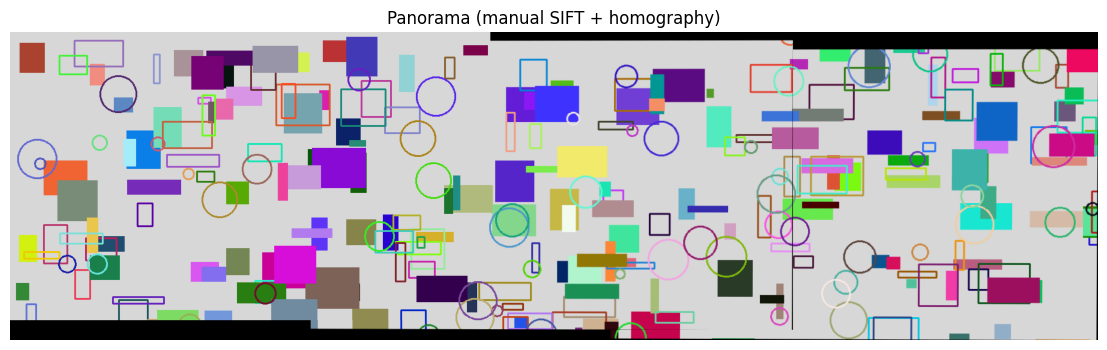

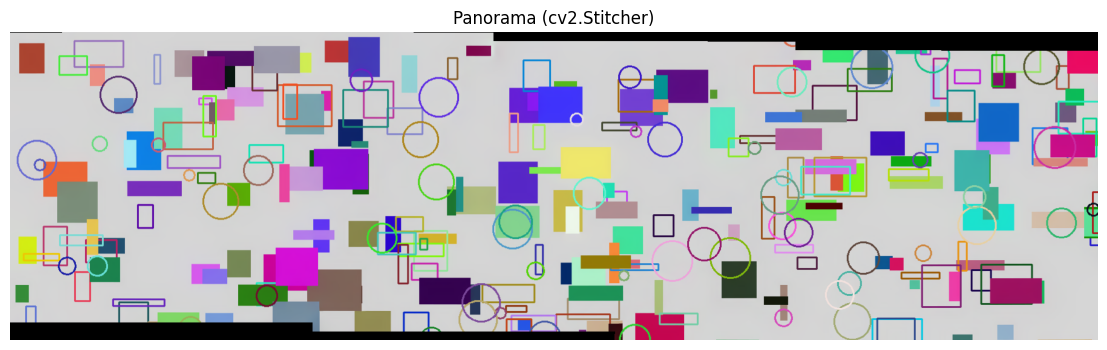

In [8]:
sift = cv2.SIFT_create()
bf = cv2.BFMatcher(cv2.NORM_L2)

def crop_black(img):
    g = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    ys, xs = np.where(g > 0)
    return img[ys.min():ys.max() + 1, xs.min():xs.max() + 1]

def stitch_pair(base, new, ratio=0.7):
    """Warp `new` into the coordinate frame of `base` and merge."""
    g1, g2 = cv2.cvtColor(base, cv2.COLOR_BGR2GRAY), cv2.cvtColor(new, cv2.COLOR_BGR2GRAY)
    k1, d1 = sift.detectAndCompute(g1, None); k2, d2 = sift.detectAndCompute(g2, None)
    pairs = bf.knnMatch(d2, d1, k=2)
    good = [m for m, n in pairs if m.distance < ratio * n.distance]
    print(f"   matches kept: {len(good)}")
    if len(good) < 10: raise RuntimeError("Not enough matches – images do not overlap enough")
    src = np.float32([k2[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)   # points in new
    dst = np.float32([k1[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)   # points in base
    H, _ = cv2.findHomography(src, dst, cv2.RANSAC, 4.0)

    hb, wb = base.shape[:2]; hn, wn = new.shape[:2]
    corners_new = cv2.perspectiveTransform(np.float32([[0, 0], [wn, 0], [wn, hn], [0, hn]]).reshape(-1, 1, 2), H)
    all_pts = np.vstack([corners_new, np.float32([[0, 0], [wb, 0], [wb, hb], [0, hb]]).reshape(-1, 1, 2)])
    xmin, ymin = np.int32(all_pts.min(axis=0).ravel() - 0.5)
    xmax, ymax = np.int32(all_pts.max(axis=0).ravel() + 0.5)
    T = np.array([[1, 0, -xmin], [0, 1, -ymin], [0, 0, 1]], np.float64)
    size = (xmax - xmin, ymax - ymin)
    new_w = cv2.warpPerspective(new, T @ H, size)
    base_w = cv2.warpPerspective(base, T, size)
    mask_b = cv2.warpPerspective(np.full((hb, wb), 255, np.uint8), T, size) > 0
    out = new_w.copy(); out[mask_b] = base_w[mask_b]
    return out

panorama = pano_imgs[0]
for i in range(1, len(pano_imgs)):
    print(f"Stitching image {i + 1} ...")
    panorama = stitch_pair(panorama, pano_imgs[i])
panorama = crop_black(panorama)
print("Panorama size:", panorama.shape[1], "x", panorama.shape[0])
show(panorama, "Panorama (manual SIFT + homography)", size=(15, 4))

# --- built-in OpenCV stitcher for comparison
status, auto = cv2.Stitcher_create(cv2.Stitcher_PANORAMA).stitch(pano_imgs)
if status == cv2.Stitcher_OK: show(auto, "Panorama (cv2.Stitcher)", size=(15, 4))
else: print("cv2.Stitcher failed, status =", status)

---
## Task 6 – Lane Detection (Hough Line Transform)
Gray → Gaussian blur → Canny → **region-of-interest** mask (road triangle) → `HoughLinesP` → split segments by slope sign
(left < 0, right > 0) → average each side into one line → overlay on the image.

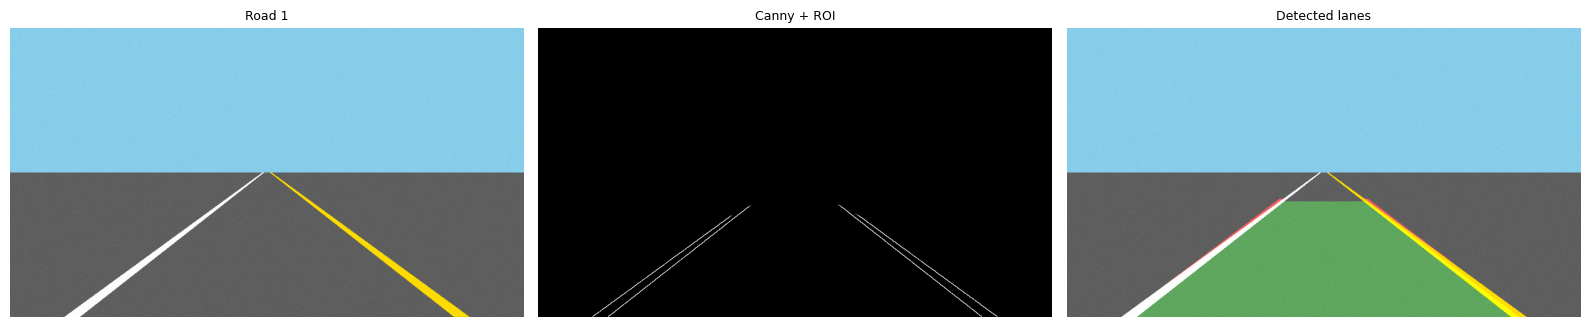

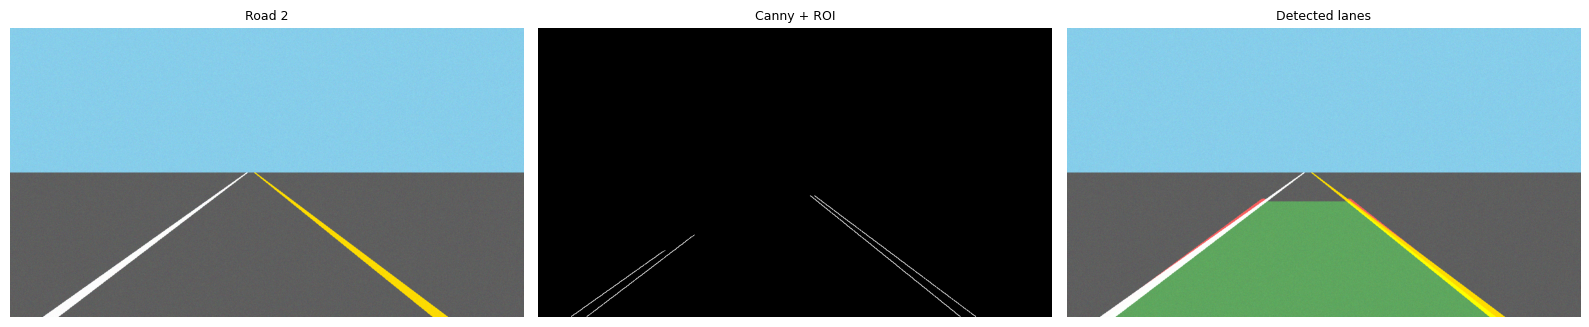

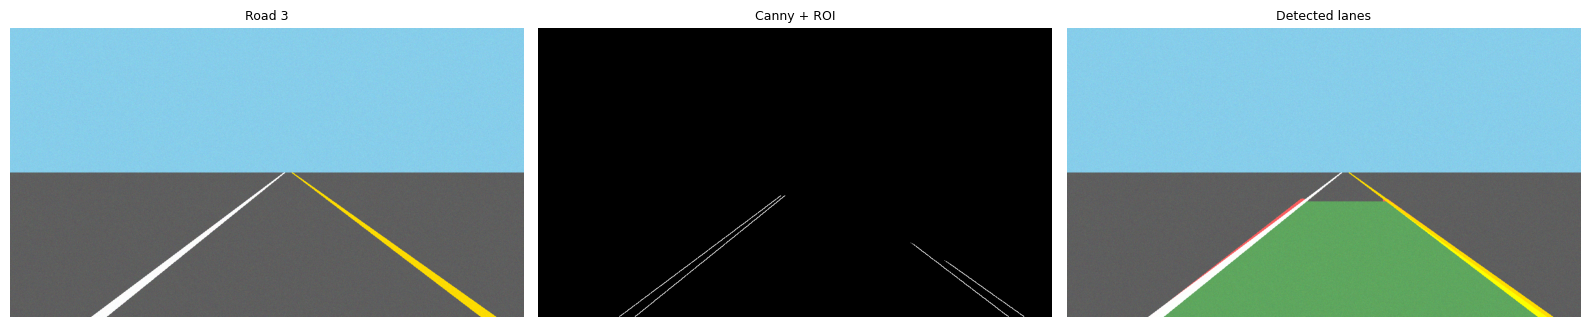

In [9]:
LANE_IMAGE_PATHS = []     # e.g. ["road1.jpg", "road2.jpg"]

def make_road(offset=0, curve=0, W=960, H=540):
    img = np.zeros((H, W, 3), np.uint8)
    img[:] = (235, 206, 135); img[int(H * .5):] = (95, 95, 95)           # sky / road
    vx, vy = W // 2 + offset, int(H * .5)                                  # vanishing point
    for bx, col in ((int(W * .12) + offset, (255, 255, 255)), (int(W * .88) + offset, (0, 220, 255))):
        top = (vx + (bx - vx) * 0.02 + curve, vy)
        pts = np.array([[bx - 14, H], [bx + 14, H], [top[0] + 1, top[1]], [top[0] - 1, top[1]]], np.int32)
        cv2.fillPoly(img, [pts], col)
    return np.clip(img + rng.normal(0, 5, img.shape), 0, 255).astype(np.uint8)

if LANE_IMAGE_PATHS: road_imgs = [cv2.imread(p) for p in LANE_IMAGE_PATHS]
else: road_imgs = [make_road(0, 0), make_road(-40, 10), make_road(50, -10)]

def average_line(segs, y_bottom, y_top):
    if not segs: return None
    xs = np.array([[s[0], s[2]] for s in segs]).ravel(); ys = np.array([[s[1], s[3]] for s in segs]).ravel()
    m, b = np.polyfit(ys, xs, 1)                       # x = m*y + b  (stable for near-vertical lines)
    return (int(m * y_bottom + b), y_bottom, int(m * y_top + b), y_top)

def detect_lanes(img):
    h, w = img.shape[:2]
    gray = cv2.GaussianBlur(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), (5, 5), 0)
    edges = cv2.Canny(gray, 50, 150)
    roi = np.zeros_like(edges)
    cv2.fillPoly(roi, [np.array([[(0, h), (w, h), (int(w * .55), int(h * .58)), (int(w * .45), int(h * .58))]], np.int32)], 255)
    masked = cv2.bitwise_and(edges, roi)
    lines = cv2.HoughLinesP(masked, 1, np.pi / 180, 40, minLineLength=40, maxLineGap=100)
    left, right = [], []
    for l in (lines if lines is not None else []):
        x1, y1, x2, y2 = l[0]
        if x2 == x1: continue
        slope = (y2 - y1) / (x2 - x1)
        if slope < -0.4: left.append(l[0])
        elif slope > 0.4: right.append(l[0])
    yb, yt = h, int(h * .6)
    L, R = average_line(left, yb, yt), average_line(right, yb, yt)
    out = img.copy(); layer = np.zeros_like(img)
    for ln in (L, R):
        if ln: cv2.line(layer, ln[:2], ln[2:], (0, 0, 255), 12)
    if L and R:
        cv2.fillPoly(layer, [np.array([L[:2], L[2:], R[2:], R[:2]], np.int32)], (0, 120, 0))
    out = cv2.addWeighted(out, 1, layer, 0.6, 0)
    return out, edges, masked

for i, im in enumerate(road_imgs):
    out, edges, masked = detect_lanes(im)
    show_grid([im, masked, out], [f"Road {i + 1}", "Canny + ROI", "Detected lanes"], cols=3, size=(16, 3.5))

---
## Task 7 – Coins Detection and Counting (Hough Circle Transform)
Gray → median blur (removes texture/noise) → `HoughCircles` (gradient method) with radius limits → draw circles & centres → count.

Detected coins: 9  (ground truth: 9)
Radii (px): [38, 42, 46, 48, 50, 52, 58, 67, 70]


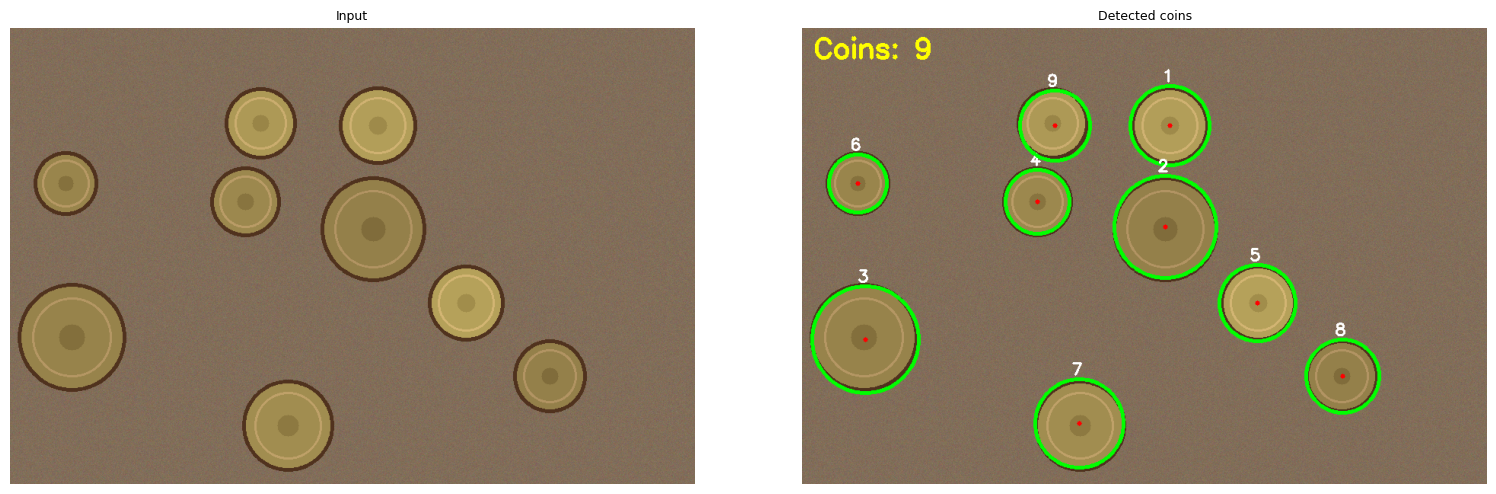

In [10]:
COINS_IMAGE_PATH = None      # e.g. "coins.jpg"

def make_coin_image(n_coins=9, W=900, H=600):
    img = np.full((H, W, 3), (90, 110, 130), np.uint8)
    img = np.clip(img + rng.normal(0, 6, img.shape), 0, 255).astype(np.uint8)
    placed = []
    while len(placed) < n_coins:
        r = int(rng.integers(35, 70)); x = int(rng.integers(r + 10, W - r - 10)); y = int(rng.integers(r + 10, H - r - 10))
        if all(np.hypot(x - a, y - b) > r + rr + 15 for a, b, rr in placed):
            placed.append((x, y, r))
            base = int(rng.integers(140, 200))
            cv2.circle(img, (x, y), r, (base // 2, base - 20, base), -1)
            cv2.circle(img, (x, y), r, (30, 50, 80), 3)
            cv2.circle(img, (x, y), int(r * .75), (base // 2 + 25, base, base + 30), 2)
            cv2.circle(img, (x, y), int(r * .25), (base // 2 - 15, base - 40, base - 20), -1)
    return img, len(placed)

if COINS_IMAGE_PATH: coins, true_n = cv2.imread(COINS_IMAGE_PATH), None
else: coins, true_n = make_coin_image()

gray = cv2.cvtColor(coins, cv2.COLOR_BGR2GRAY)
gray_blur = cv2.medianBlur(gray, 7)
circles = cv2.HoughCircles(gray_blur, cv2.HOUGH_GRADIENT, dp=1.2, minDist=60,
                           param1=100, param2=40, minRadius=25, maxRadius=80)

result = coins.copy(); count = 0
if circles is not None:
    circles = np.uint16(np.around(circles[0]))
    count = len(circles)
    for i, (x, y, r) in enumerate(circles, 1):
        cv2.circle(result, (x, y), r, (0, 255, 0), 3)
        cv2.circle(result, (x, y), 3, (0, 0, 255), -1)
        cv2.putText(result, str(i), (x - 10, y - r - 6), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
cv2.putText(result, f"Coins: {count}", (15, 40), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 255), 3)

print(f"Detected coins: {count}" + (f"  (ground truth: {true_n})" if true_n else ""))
if count: print("Radii (px):", sorted(int(c[2]) for c in circles))
show_grid([coins, result], ["Input", "Detected coins"], cols=2, size=(16, 5))

---
## Task 8 – Smart Security System (boundary detection in a security zone + alarm)
* A **security zone** (polygon/rectangle) is predefined.
* **MOG2 background subtraction** isolates moving/new objects; the mask is restricted to the zone, cleaned with morphology.
* `findContours` extracts the **boundary** of each object inside the zone.
* If a contour larger than `MIN_AREA` is in the zone → **ALARM** (red zone + text; `print`/beep hook provided).

Frames processed: 100
Alarm triggered in frames: 65 → 84  (20 frames)


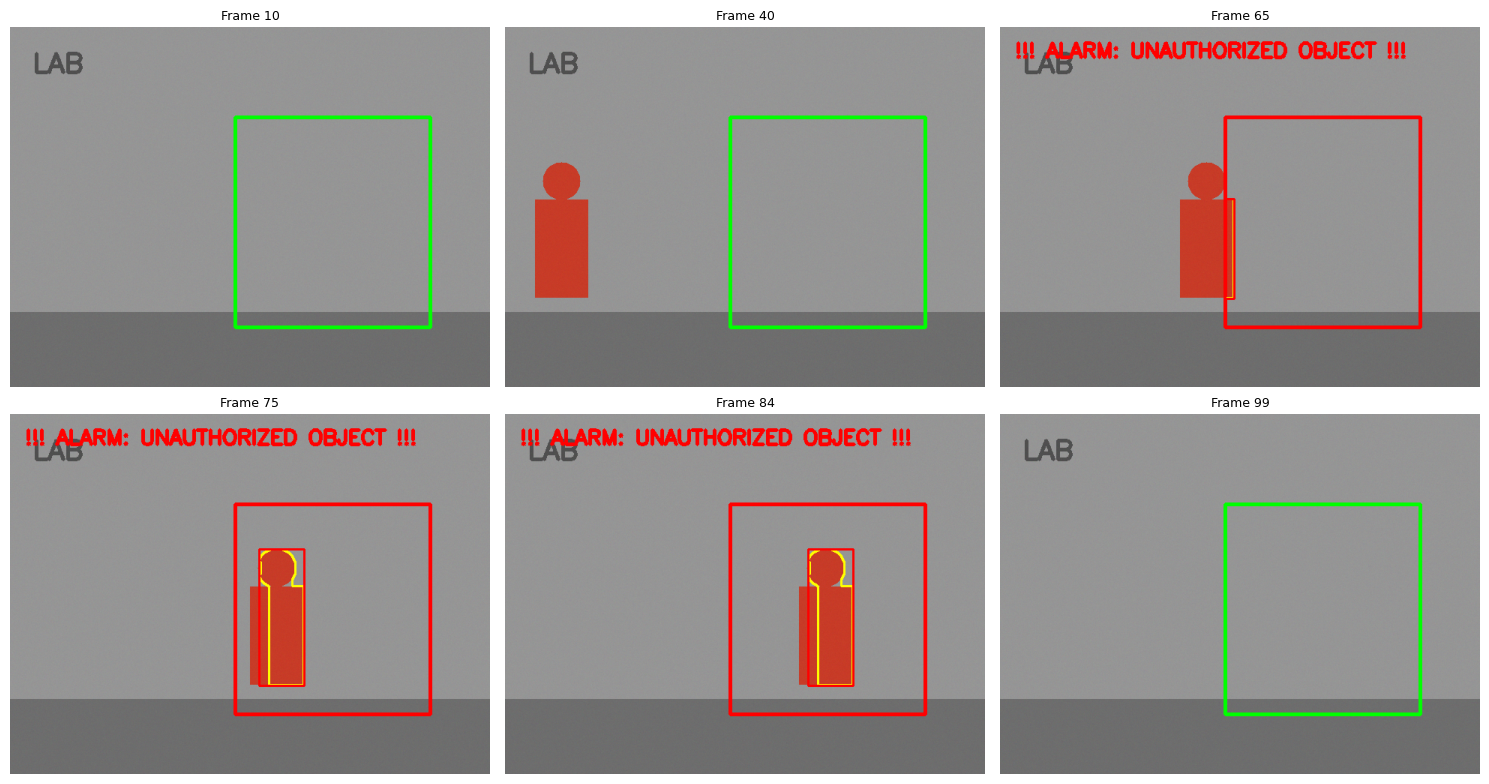

In [11]:
SECURITY_SOURCE = None      # None = synthetic stream, or a video path, or 0 for a webcam
ZONE = np.array([[300, 120], [560, 120], [560, 400], [300, 400]], np.int32)   # (x, y) corners of the sensitive area
MIN_AREA = 1200

def synthetic_stream(n=100, W=640, H=480):
    bg = np.zeros((H, W, 3), np.uint8)
    bg[:] = (150, 150, 150); cv2.rectangle(bg, (0, 380), (W, H), (110, 110, 110), -1)
    cv2.putText(bg, "LAB", (30, 60), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (80, 80, 80), 3)
    for i in range(n):
        f = bg.copy()
        if i > 25:                                          # intruder walks in from the left, enters zone ~frame 55
            x = int(-80 + (i - 25) * 8)
            if i < 85: cv2.rectangle(f, (x, 230), (x + 70, 360), (40, 60, 200), -1); cv2.circle(f, (x + 35, 205), 25, (40, 60, 200), -1)
        yield np.clip(f + rng.normal(0, 2, f.shape), 0, 255).astype(np.uint8)

def stream(src):
    if src is None: yield from synthetic_stream(); return
    cap = cv2.VideoCapture(src)
    while True:
        ok, fr = cap.read()
        if not ok: break
        yield fr
    cap.release()

zone_mask = None
backsub = cv2.createBackgroundSubtractorMOG2(history=60, varThreshold=40, detectShadows=False)
kernel = np.ones((5, 5), np.uint8)
frames_out, alarm_frames = [], []

for i, frame in enumerate(stream(SECURITY_SOURCE)):
    if zone_mask is None:
        zone_mask = np.zeros(frame.shape[:2], np.uint8); cv2.fillPoly(zone_mask, [ZONE], 255)
    fg = backsub.apply(cv2.GaussianBlur(frame, (5, 5), 0))
    fg = cv2.threshold(fg, 200, 255, cv2.THRESH_BINARY)[1]
    fg = cv2.bitwise_and(fg, zone_mask)                                         # only look inside the zone
    fg = cv2.morphologyEx(fg, cv2.MORPH_OPEN, kernel)
    fg = cv2.morphologyEx(fg, cv2.MORPH_CLOSE, kernel, iterations=2)
    cnts, _ = cv2.findContours(fg, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = [c for c in cnts if cv2.contourArea(c) > MIN_AREA]
    alarm = len(cnts) > 0 and i > 20                                            # skip background warm-up

    vis = frame.copy()
    cv2.polylines(vis, [ZONE], True, (0, 0, 255) if alarm else (0, 255, 0), 3)
    cv2.drawContours(vis, cnts, -1, (0, 255, 255), 2)                           # object boundary
    for c in cnts:
        x, y, w, h = cv2.boundingRect(c); cv2.rectangle(vis, (x, y), (x + w, y + h), (0, 0, 255), 2)
    if alarm:
        cv2.putText(vis, "!!! ALARM: UNAUTHORIZED OBJECT !!!", (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 255), 3)
        alarm_frames.append(i)
        # print("\a")   # terminal beep ; on Windows: import winsound; winsound.Beep(1000, 300)
    # cv2.imshow("Security", vis); cv2.waitKey(1)   # <- uncomment for live window outside Jupyter
    frames_out.append(vis)

print(f"Frames processed: {len(frames_out)}")
print("Alarm triggered in frames:", (f"{alarm_frames[0]} → {alarm_frames[-1]}  ({len(alarm_frames)} frames)" if alarm_frames else "none"))
pick = [10, 40, (alarm_frames[0] if alarm_frames else 55), (alarm_frames[len(alarm_frames) // 2] if alarm_frames else 65),
        (alarm_frames[-1] if alarm_frames else 80), len(frames_out) - 1]
show_grid([frames_out[p] for p in pick], [f"Frame {p}" for p in pick], cols=3, size=(15, 4))

---
### ✅ All 8 tasks complete
Change the `*_PATH` variables at the top of each task to run on your own lab images / videos.